## Introduction
Greetings from the Kaggle bot! This is an automatically-generated kernel with starter code demonstrating how to read in the data and begin exploring. Click the blue "Edit Notebook" or "Fork Notebook" button at the top of this kernel to begin editing.

## Exploratory Analysis
To begin this exploratory analysis, first use `matplotlib` to import libraries and define functions for plotting the data. Depending on the data, not all plots will be made. (Hey, I'm just a kerneling bot, not a Kaggle Competitions Grandmaster!)

Splitting dataset (this may take a few minutes)...

Dataset split complete:
Parasitized: {'train': 9645, 'val': 2066, 'test': 2068}
Uninfected: {'train': 9645, 'val': 2066, 'test': 2068}

CSV METADATA CREATED
Train: 19290 samples | {'Parasitized': 9645, 'Uninfected': 9645}
Val  : 4132 samples | {'Parasitized': 2066, 'Uninfected': 2066}
Test : 4136 samples | {'Parasitized': 2068, 'Uninfected': 2068}

DATALOADERS READY
Train batches: 603
Val batches: 130
Test batches: 130


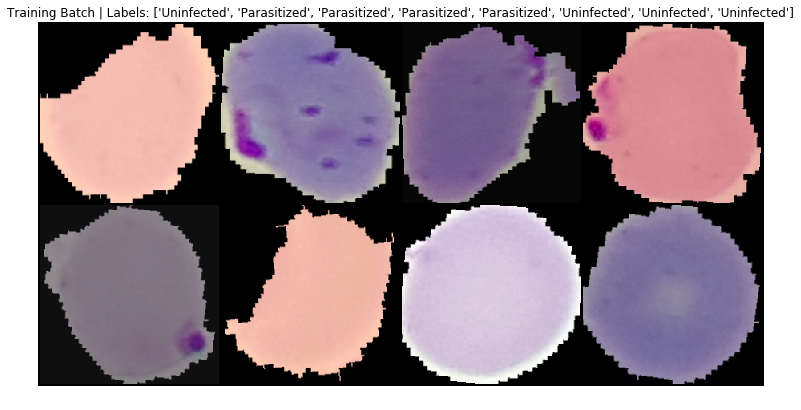

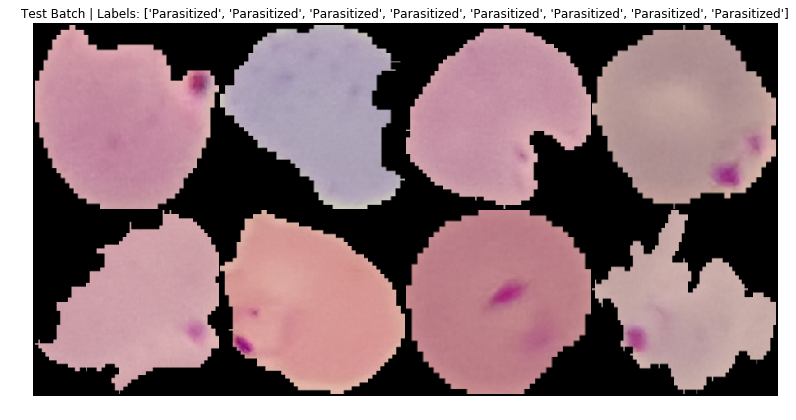


✅ Full dataset loaded and ready for training!


In [10]:
import os
import random
import shutil
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt

# ============================
# SEED & CONFIG
# ============================
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Dataset paths
DATASET_ROOT = "/kaggle/input/cell_images"
PARA_DIR = os.path.join(DATASET_ROOT, "Parasitized")
UNINF_DIR = os.path.join(DATASET_ROOT, "Uninfected")

# Working directory
WORK_DIR = "/kaggle/working"
SPLIT_DIR = os.path.join(WORK_DIR, "malaria_split_full")

# Split ratios
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}
CLASSES = ["Parasitized", "Uninfected"]

# ============================
# CREATE SPLIT DIRECTORIES
# ============================
for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# ============================
# SPLIT FULL DATASET
# ============================
def split_class_images(class_name, src_dir):
    """Split all images from a class into train/val/test"""
    images = [f for f in os.listdir(src_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)
    
    n_total = len(images)
    n_train = int(SPLITS["train"] * n_total)
    n_val = int(SPLITS["val"] * n_total)
    
    splits = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:]
    }
    
    # Copy images to split directories
    for split, files in splits.items():
        for f in files:
            src = os.path.join(src_dir, f)
            dst = os.path.join(SPLIT_DIR, split, class_name, f)
            shutil.copy(src, dst)
    
    return {k: len(v) for k, v in splits.items()}

# Split both classes
print("Splitting dataset (this may take a few minutes)...")
counts = {}
counts["Parasitized"] = split_class_images("Parasitized", PARA_DIR)
counts["Uninfected"] = split_class_images("Uninfected", UNINF_DIR)

print("\nDataset split complete:")
print(f"Parasitized: {counts['Parasitized']}")
print(f"Uninfected: {counts['Uninfected']}")

# ============================
# CREATE METADATA CSVs
# ============================
def make_csv(split_name, out_csv):
    """Create CSV with filepath and label columns"""
    rows = []
    base = os.path.join(SPLIT_DIR, split_name)
    
    for cls in CLASSES:
        class_dir = os.path.join(base, cls)
        for img in os.listdir(class_dir):
            rows.append({
                "filepath": os.path.join(class_dir, img),
                "label": cls
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

# Create CSVs
train_csv = os.path.join(WORK_DIR, "train_full.csv")
val_csv = os.path.join(WORK_DIR, "val_full.csv")
test_csv = os.path.join(WORK_DIR, "test_full.csv")

df_train = make_csv("train", train_csv)
df_val = make_csv("val", val_csv)
df_test = make_csv("test", test_csv)

print("\n" + "="*50)
print("CSV METADATA CREATED")
print("="*50)
print(f"Train: {len(df_train)} samples | {df_train['label'].value_counts().to_dict()}")
print(f"Val  : {len(df_val)} samples | {df_val['label'].value_counts().to_dict()}")
print(f"Test : {len(df_test)} samples | {df_test['label'].value_counts().to_dict()}")

# ============================
# DATASET CLASS
# ============================
label2idx = {"Parasitized": 0, "Uninfected": 1}
idx2label = {v: k for k, v in label2idx.items()}

class MalariaDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]["filepath"]
        label_str = self.data.iloc[idx]["label"]
        
        image = Image.open(img_path).convert("RGB")
        label = label2idx[label_str]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================
# TRANSFORMS
# ============================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# ============================
# CREATE DATASETS & LOADERS
# ============================
train_dataset = MalariaDataset(train_csv, transform=train_transform)
val_dataset = MalariaDataset(val_csv, transform=test_transform)
test_dataset = MalariaDataset(test_csv, transform=test_transform)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\n" + "="*50)
print("DATALOADERS READY")
print("="*50)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================
# VISUALIZATION
# ============================
def show_batch(loader, title):
    images, labels = next(iter(loader))
    
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)
    
    grid = torchvision.utils.make_grid(images[:8], nrow=4)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"{title} | Labels: {[idx2label[int(l)] for l in labels[:8]]}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show sample batches
show_batch(train_loader, "Training Batch")
show_batch(test_loader, "Test Batch")

print("\n✅ Full dataset loaded and ready for training!")

In [15]:
# ====================================================================
# COMPLETE BIPA PIPELINE FOR MALARIA CELL CLASSIFICATION (KAGGLE)
# Includes: Heuristic BAM + End-to-End Training
# No external dependencies (no YOLO, works with standard Kaggle libraries)
# ====================================================================

import os
import time
import random
import shutil
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import seaborn as sns
from torchvision import transforms

# ============================
# SEED & CONFIG
# ============================
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset paths
DATASET_ROOT = "/kaggle/input/cell_images"
PARA_DIR = os.path.join(DATASET_ROOT, "Parasitized")
UNINF_DIR = os.path.join(DATASET_ROOT, "Uninfected")

# Working directory
WORK_DIR = "/kaggle/working"
SPLIT_DIR = os.path.join(WORK_DIR, "malaria_split_full")

# Training config
IMG_SIZE = 224
PATCH_SIZE = 8  # Micro-patches for fine-grained features
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model architecture
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0

# Split ratios
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}
CLASSES = ["Parasitized", "Uninfected"]

print("="*60)
print("BIPA FOR MALARIA CELL CLASSIFICATION")
print("="*60)
print(f"Device: {DEVICE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {(IMG_SIZE//PATCH_SIZE)**2}")

# ============================
# STEP 1: DATASET SPLITTING
# ============================
print("\n" + "="*60)
print("STEP 1: DATASET SPLITTING")
print("="*60)

# Create split directories
for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

def split_class_images(class_name, src_dir):
    """Split all images from a class into train/val/test"""
    images = [f for f in os.listdir(src_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)
    
    n_total = len(images)
    n_train = int(SPLITS["train"] * n_total)
    n_val = int(SPLITS["val"] * n_total)
    
    splits = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:]
    }
    
    print(f"  Copying {class_name} images...")
    for split, files in splits.items():
        for f in files:
            src = os.path.join(src_dir, f)
            dst = os.path.join(SPLIT_DIR, split, class_name, f)
            shutil.copy(src, dst)
    
    return {k: len(v) for k, v in splits.items()}

# Split both classes
counts = {}
counts["Parasitized"] = split_class_images("Parasitized", PARA_DIR)
counts["Uninfected"] = split_class_images("Uninfected", UNINF_DIR)

print("\n✓ Dataset split complete:")
print(f"   Parasitized: {counts['Parasitized']}")
print(f"   Uninfected: {counts['Uninfected']}")

# Create metadata CSVs
def make_csv(split_name, out_csv):
    """Create CSV with filepath and label columns"""
    rows = []
    base = os.path.join(SPLIT_DIR, split_name)
    
    for cls in CLASSES:
        class_dir = os.path.join(base, cls)
        for img in os.listdir(class_dir):
            rows.append({
                "filepath": os.path.join(class_dir, img),
                "label": cls
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

train_csv = os.path.join(WORK_DIR, "train_full.csv")
val_csv = os.path.join(WORK_DIR, "val_full.csv")
test_csv = os.path.join(WORK_DIR, "test_full.csv")

df_train = make_csv("train", train_csv)
df_val = make_csv("val", val_csv)
df_test = make_csv("test", test_csv)

print("\n✓ CSV metadata created:")
print(f"   Train: {len(df_train)} samples | {df_train['label'].value_counts().to_dict()}")
print(f"   Val:   {len(df_val)} samples | {df_val['label'].value_counts().to_dict()}")
print(f"   Test:  {len(df_test)} samples | {df_test['label'].value_counts().to_dict()}")

# Build label mapping
label2idx = {"Parasitized": 0, "Uninfected": 1}
idx2label = {v: k for k, v in label2idx.items()}
NUM_CLASSES = len(label2idx)

# ============================
# STEP 2: HEURISTIC BAM FILTERS
# ============================
print("\n" + "="*60)
print("STEP 2: HEURISTIC BAM FILTERS")
print("="*60)

class HeuristicBAMFilters:
    """
    Bio-inspired filters for extracting texture, edges, and contours.
    These serve as auxiliary input to guide A-BAMNet.
    """
    def __init__(self):
        # Gabor-like filters for texture (simulated without skimage dependency)
        self.orientations = [0, 45, 90, 135]
        self.frequencies = [0.1, 0.15, 0.2]
    
    def apply_texture_filters(self, img_gray):
        """Extract texture features using multi-scale filtering"""
        responses = []
        
        # Convert to uint8 for OpenCV compatibility
        img_uint8 = (img_gray * 255).astype(np.uint8)
        
        # Sobel filters at different orientations
        sobel_x = cv2.Sobel(img_uint8, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img_uint8, cv2.CV_64F, 0, 1, ksize=3)
        responses.append(np.abs(sobel_x))
        responses.append(np.abs(sobel_y))
        
        # Scharr filters (stronger edge response)
        scharr_x = cv2.Scharr(img_uint8, cv2.CV_64F, 1, 0)
        scharr_y = cv2.Scharr(img_uint8, cv2.CV_64F, 0, 1)
        responses.append(np.abs(scharr_x))
        responses.append(np.abs(scharr_y))
        
        # Multi-scale Laplacian
        for sigma in [1.0, 2.0, 3.0]:
            blurred = cv2.GaussianBlur(img_uint8, (0, 0), sigma)
            laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
            responses.append(np.abs(laplacian))
        
        # Aggregate: max response across filters
        return np.max(responses, axis=0)
    
    def apply_log(self, img_gray, sigma=2.0):
        """Laplacian of Gaussian for blob detection"""
        # Convert to uint8 for OpenCV compatibility
        img_uint8 = (img_gray * 255).astype(np.uint8)
        blurred = cv2.GaussianBlur(img_uint8, (0, 0), sigma)
        log_filter = cv2.Laplacian(blurred, cv2.CV_64F)
        return np.abs(log_filter)
    
    def apply_contours(self, img_gray):
        """Contour detection for cell boundaries"""
        edges = cv2.Canny((img_gray * 255).astype(np.uint8), 50, 150)
        # Dilate to make contours more prominent
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        return edges.astype(np.float32) / 255.0
    
    def generate_heuristic_bam(self, img_pil):
        """
        Generate heuristic BAM from PIL image
        Returns: H x W feature map highlighting biological regions
        """
        # Convert to grayscale numpy
        img_gray = np.array(img_pil.convert('L')).astype(np.float32) / 255.0
        
        # Apply filters
        texture_map = self.apply_texture_filters(img_gray)
        log_map = self.apply_log(img_gray)
        contour_map = self.apply_contours(img_gray)
        
        # Normalize each map to [0, 1]
        texture_map = (texture_map - texture_map.min()) / (texture_map.max() - texture_map.min() + 1e-8)
        log_map = (log_map - log_map.min()) / (log_map.max() - log_map.min() + 1e-8)
        
        # Aggregate: weighted sum (emphasize texture for cell structures)
        M_raw = 0.5 * texture_map + 0.3 * log_map + 0.2 * contour_map
        
        # Normalize to [0, 1]
        M_raw = (M_raw - M_raw.min()) / (M_raw.max() - M_raw.min() + 1e-8)
        
        return M_raw

print("✓ Heuristic BAM filters initialized")

# ============================
# STEP 3: DATASET WITH BAM
# ============================
print("\n" + "="*60)
print("STEP 3: DATASET PREPARATION")
print("="*60)

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

class MalariaDatasetWithBAM(Dataset):
    def __init__(self, csv_file, label2idx, transform=None, generate_heuristic=True):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.generate_heuristic = generate_heuristic
        
        if generate_heuristic:
            self.bam_filter = HeuristicBAMFilters()
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label_str = self.data.iloc[idx]['label']
        label = self.label2idx[label_str]
        
        # Load image
        img_pil = Image.open(img_path).convert('RGB')
        
        # Generate heuristic BAM if needed
        if self.generate_heuristic:
            heuristic_bam = self.bam_filter.generate_heuristic_bam(img_pil)
            heuristic_bam = torch.from_numpy(heuristic_bam).float()
        else:
            heuristic_bam = torch.zeros((IMG_SIZE, IMG_SIZE), dtype=torch.float32)
        
        # Apply transforms
        img_tensor = self.transform(img_pil)
        
        return img_tensor, label, heuristic_bam, img_path

# Create datasets
train_dataset = MalariaDatasetWithBAM(train_csv, label2idx, transform=train_transform, generate_heuristic=True)
val_dataset = MalariaDatasetWithBAM(val_csv, label2idx, transform=test_transform, generate_heuristic=True)
test_dataset = MalariaDatasetWithBAM(test_csv, label2idx, transform=test_transform, generate_heuristic=True)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ Datasets ready:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

# ============================
# STEP 4: BIPA MODEL
# ============================
print("\n" + "="*60)
print("STEP 4: BIPA MODEL ARCHITECTURE")
print("="*60)

class PatchEmbed(nn.Module):
    """Micro-patch embedding with learnable positional encoding"""
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches_side = img_size // patch_size
        self.num_patches = self.n_patches_side ** 2
        
        # Convolutional projection
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # Learnable CLS token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        
        # Initialize
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
    
    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        
        return x

class ABAMNet(nn.Module):
    """Adaptive BAM Generator with heuristic feature injection"""
    def __init__(self, in_ch=3, base_ch=32, use_heuristic=True):
        super().__init__()
        self.use_heuristic = use_heuristic
        
        input_channels = in_ch + 1 if use_heuristic else in_ch
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
            nn.BatchNorm2d(base_ch // 2),
            nn.ReLU(inplace=True)
        )
        
        self.out = nn.Conv2d(base_ch // 2, 1, 1)
    
    def forward(self, x, heuristic_bam=None):
        if self.use_heuristic and heuristic_bam is not None:
            heuristic_bam = heuristic_bam.unsqueeze(1)
            x = torch.cat([x, heuristic_bam], dim=1)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.out(x)
        
        return x.squeeze(1)

class BIPA_MultiHeadAttention(nn.Module):
    """Multi-head attention with BAM modulation"""
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        
        # Learnable alpha for BAM influence
        self.alpha = nn.Parameter(torch.ones(1))
    
    def forward(self, x, mb):
        B, L, D = x.shape
        
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        
        # BAM modulation
        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)
        mb_bias = mb_with_cls.unsqueeze(1).unsqueeze(2)
        mb_bias = mb_bias.expand(-1, self.num_heads, L, -1)
        
        attn = attn + self.alpha * mb_bias
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, L, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        
        return x

class BIPABlock(nn.Module):
    """BIPA Transformer encoder block"""
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(drop)
        )
    
    def forward(self, x, mb):
        x = x + self.attn(self.norm1(x), mb)
        x = x + self.mlp(self.norm2(x))
        return x

class BIPA(nn.Module):
    """Complete BIPA Model"""
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=DEPTH,
                 num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.abam = ABAMNet(in_ch=in_chans, base_ch=32, use_heuristic=True)
        
        self.blocks = nn.ModuleList([
            BIPABlock(embed_dim, num_heads, mlp_ratio, drop_rate, drop_rate)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.pos_drop = nn.Dropout(p=drop_rate)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def forward(self, x, heuristic_bam=None):
        B = x.shape[0]
        
        tokens = self.patch_embed(x)
        tokens = self.pos_drop(tokens)
        
        raw_bam = self.abam(x, heuristic_bam)
        
        # Patch-level averaging
        ps = self.patch_size
        bam_patches = raw_bam.unfold(1, ps, ps).unfold(2, ps, ps)
        bam_patches = bam_patches.contiguous().view(B, -1, ps * ps)
        mb = bam_patches.mean(dim=2)
        mb = torch.sigmoid(mb)
        
        for block in self.blocks:
            tokens = block(tokens, mb)
        
        cls_token = tokens[:, 0]
        cls_token = self.norm(cls_token)
        logits = self.head(cls_token)
        
        return logits, raw_bam, mb

# Initialize model
model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model: BIPA")
print(f"   Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"   Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"   Embed dim: {EMBED_DIM}")
print(f"   Depth: {DEPTH} blocks")
print(f"   Num heads: {NUM_HEADS}")

# ============================
# STEP 5: TRAINING
# ============================
print("\n" + "="*60)
print("STEP 5: TRAINING")
print("="*60)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_idx, (images, labels, heuristic_bams, paths) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        heuristic_bams = heuristic_bams.to(device)
        
        logits, raw_bam, mb = model(images, heuristic_bams)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    
    return avg_loss, acc

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for images, labels, heuristic_bams, paths in loader:
            images = images.to(device)
            heuristic_bams = heuristic_bams.to(device)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.time()
            
            logits, raw_bam, mb = model(images, heuristic_bams)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t1 = time.time()
            
            inference_times.append((t1 - t0) / images.shape[0])
            
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_infer_ms = np.mean(inference_times) * 1000
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'infer_ms': avg_infer_ms,
        'predictions': all_preds,
        'labels': all_labels
    }

# Training setup
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

BEST_MODEL_PATH = os.path.join(WORK_DIR, "BIPA_malaria_best.pth")
best_f1 = -1.0
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

# Training loop
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # Validate
    val_metrics = evaluate_model(model, val_loader, DEVICE)
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Acc: {val_metrics['accuracy']*100:.2f}% | F1: {val_metrics['f1']:.4f}")
    
    # Save best model
    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✓ Best model saved (F1: {best_f1:.4f})")

# ============================
# STEP 6: FINAL EVALUATION
# ============================
print("\n" + "="*60)
print("STEP 6: FINAL EVALUATION ON TEST SET")
print("="*60)

# Load best model
best_model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)

final_metrics = evaluate_model(best_model, test_loader, DEVICE)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Accuracy:  {final_metrics['accuracy']*100:.2f}%")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall:    {final_metrics['recall']:.4f}")
print(f"F1 Score:  {final_metrics['f1']:.4f}")
print(f"Inference: {final_metrics['infer_ms']:.2f} ms/image")
print("="*60)

# ============================
# STEP 7: VISUALIZATIONS
# ============================
print("\n" + "="*60)
print("STEP 7: GENERATING VISUALIZATIONS")
print("="*60)

# Confusion Matrix
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2idx.keys()),
            yticklabels=list(label2idx.keys()))
plt.title('Confusion Matrix - BIPA Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_acc_percent = [x * 100 for x in history['train_acc']]
val_acc_percent = [x * 100 for x in history['val_acc']]
axes[1].plot(epochs_range, train_acc_percent, 'g-', label='Train Acc')
axes[1].plot(epochs_range, val_acc_percent, 'r-', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Progress')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

# BAM Visualization
def visualize_bam_attention(model, dataset, num_samples=6):
    """Visualize learned BAM attention maps"""
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, label, heuristic_bam, path = dataset[idx]
            
            # Unnormalize for display
            img_display = img_tensor.clone()
            mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
            std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
            img_display = img_display * std + mean
            img_display = img_display.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(img_display, 0, 1)
            
            # Forward pass
            img_batch = img_tensor.unsqueeze(0).to(DEVICE)
            heuristic_batch = heuristic_bam.unsqueeze(0).to(DEVICE)
            logits, raw_bam, mb = model(img_batch, heuristic_batch)
            
            pred_class = logits.argmax(dim=1).item()
            true_class = label
            
            # Get BAM
            bam_map = raw_bam[0].cpu().numpy()
            bam_map = (bam_map - bam_map.min()) / (bam_map.max() - bam_map.min() + 1e-8)
            
            # Plot
            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title(f'Original\nTrue: {idx2label[true_class]}', fontsize=10)
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(heuristic_bam.cpu().numpy(), cmap='hot')
            axes[i, 1].set_title('Heuristic BAM', fontsize=10)
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(img_display)
            axes[i, 2].imshow(bam_map, cmap='jet', alpha=0.5)
            axes[i, 2].set_title(f'Learned BAM\nPred: {idx2label[pred_class]}', fontsize=10)
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'bam_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

visualize_bam_attention(best_model, test_dataset, num_samples=6)

print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)
print(f"✓ Best model saved: {BEST_MODEL_PATH}")
print(f"✓ Final F1 Score: {final_metrics['f1']:.4f}")
print(f"✓ Final Accuracy: {final_metrics['accuracy']*100:.2f}%")
print(f"✓ Visualizations saved in: {WORK_DIR}")

BIPA FOR MALARIA CELL CLASSIFICATION
Device: cuda
Image Size: 224x224
Patch Size: 8x8
Number of patches: 784

STEP 1: DATASET SPLITTING
  Copying Parasitized images...
  Copying Uninfected images...

✓ Dataset split complete:
   Parasitized: {'train': 9645, 'val': 2066, 'test': 2068}
   Uninfected: {'train': 9645, 'val': 2066, 'test': 2068}

✓ CSV metadata created:
   Train: 19290 samples | {'Parasitized': 9645, 'Uninfected': 9645}
   Val:   4132 samples | {'Parasitized': 2066, 'Uninfected': 2066}
   Test:  4136 samples | {'Parasitized': 2068, 'Uninfected': 2068}

STEP 2: HEURISTIC BAM FILTERS
✓ Heuristic BAM filters initialized

STEP 3: DATASET PREPARATION
✓ Datasets ready:
   Train: 19290 samples
   Val:   4132 samples
   Test:  4136 samples

STEP 4: BIPA MODEL ARCHITECTURE
✓ Model: BIPA
   Total parameters: 934,151 (0.93M)
   Trainable parameters: 934,151 (0.93M)
   Embed dim: 128
   Depth: 4 blocks
   Num heads: 8

STEP 5: TRAINING

Epoch [1/30]
------------------------------------

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/opt/conda/lib/python3.6/site-packages/torch/utils/data/_utils/worker.py", line 178, in _worker_loop
    data = fetcher.fetch(index)
  File "/opt/conda/lib/python3.6/site-packages/torch/utils/data/_utils/fetch.py", line 47, in fetch
    return self.collate_fn(data)
  File "/opt/conda/lib/python3.6/site-packages/torch/utils/data/_utils/collate.py", line 80, in default_collate
    return [default_collate(samples) for samples in transposed]
  File "/opt/conda/lib/python3.6/site-packages/torch/utils/data/_utils/collate.py", line 80, in <listcomp>
    return [default_collate(samples) for samples in transposed]
  File "/opt/conda/lib/python3.6/site-packages/torch/utils/data/_utils/collate.py", line 56, in default_collate
    return torch.stack(batch, 0, out=out)
RuntimeError: invalid argument 0: Sizes of tensors must match except in dimension 0. Got 124 and 127 in dimension 1

BIPA FOR MALARIA CELL CLASSIFICATION
Device: cuda
Image Size: 224x224
Patch Size: 8x8
Number of patches: 784

STEP 1: DATASET SPLITTING
  Copying Parasitized images...
  Copying Uninfected images...

✓ Dataset split complete:
   Parasitized: {'train': 9645, 'val': 2066, 'test': 2068}
   Uninfected: {'train': 9645, 'val': 2066, 'test': 2068}

✓ CSV metadata created:
   Train: 19290 samples
   Val:   4132 samples
   Test:  4136 samples

STEP 2: HEURISTIC BAM FILTERS
✓ Heuristic BAM filters initialized

STEP 3: DATASET PREPARATION
✓ Datasets ready:
   Train: 19290 samples
   Val:   4132 samples
   Test:  4136 samples

STEP 4: BIPA MODEL ARCHITECTURE
✓ Model: BIPA
   Total parameters: 934,151 (0.93M)

STEP 5: TRAINING

Epoch [1/10]
----------------------------------------
Train Loss: 0.3172 | Train Acc: 84.74%
Val Acc: 95.60% | F1: 0.9559
✓ Best model saved (F1: 0.9559)

Epoch [2/10]
----------------------------------------
Train Loss: 0.1390 | Train Acc: 95.84%
Val Acc: 95.81% | F1: 0.958

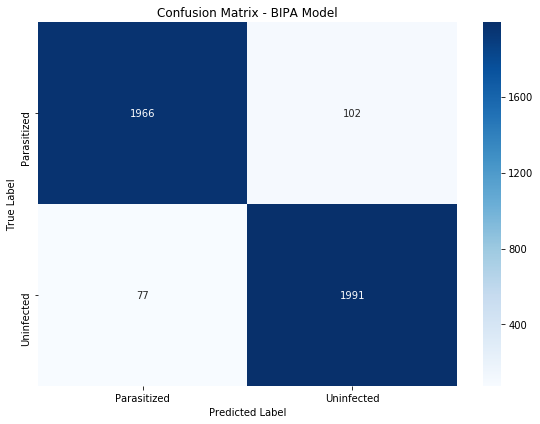

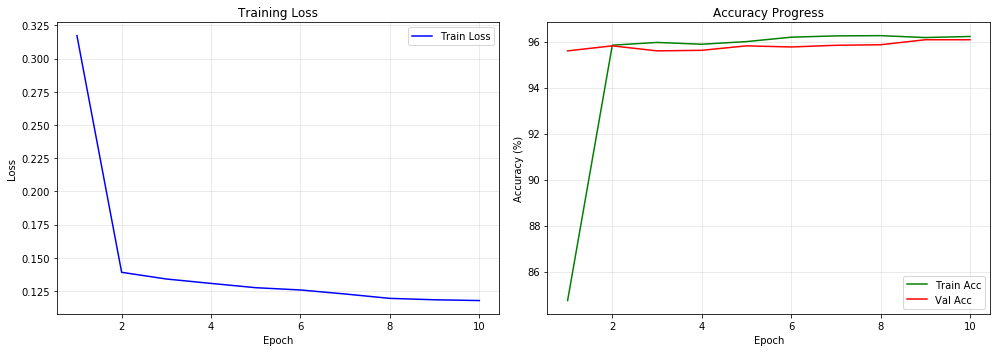

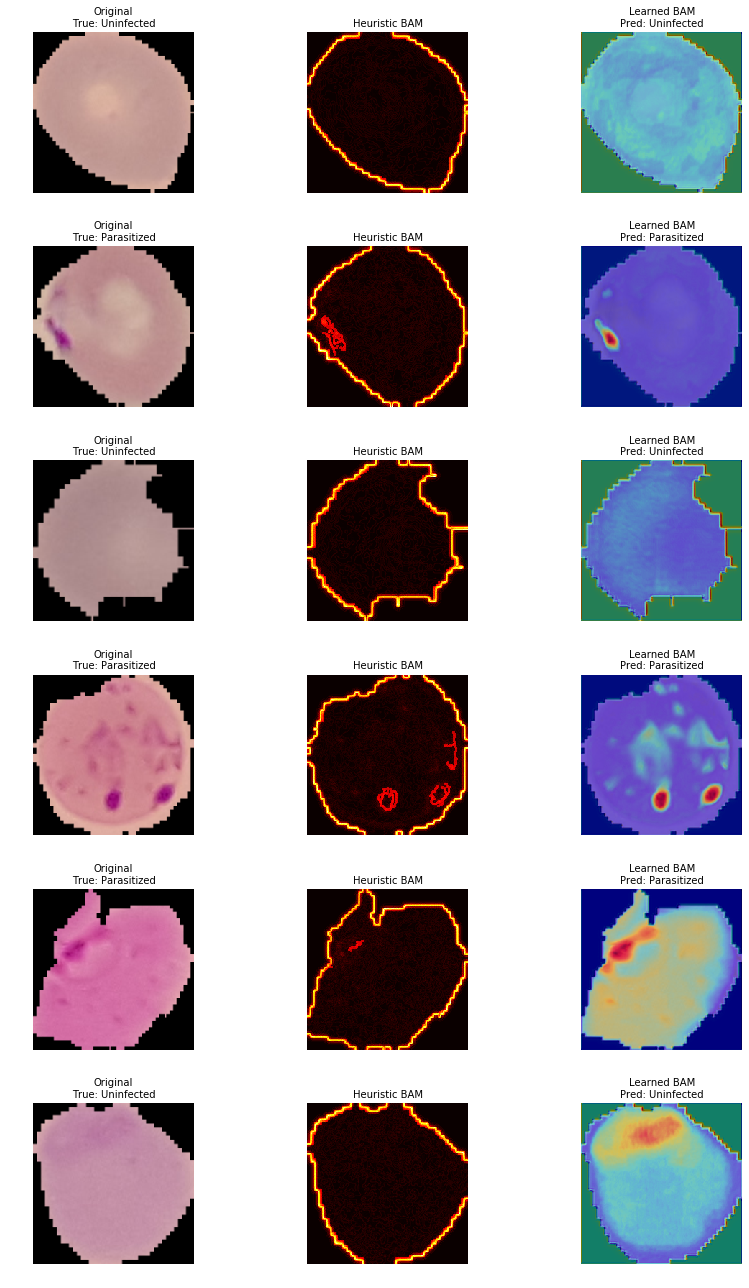


PIPELINE COMPLETE!
✓ Best model: /kaggle/working/BIPA_malaria_best.pth
✓ Final F1: 0.9567
✓ Final Accuracy: 95.67%


In [18]:
# ====================================================================
# COMPLETE BIPA PIPELINE FOR MALARIA CELL CLASSIFICATION (KAGGLE)
# Fixed version with proper image size handling
# ====================================================================

import os
import time
import random
import shutil
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import seaborn as sns
from torchvision import transforms

# ============================
# SEED & CONFIG
# ============================
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset paths
DATASET_ROOT = "/kaggle/input/cell_images"
PARA_DIR = os.path.join(DATASET_ROOT, "Parasitized")
UNINF_DIR = os.path.join(DATASET_ROOT, "Uninfected")

# Working directory
WORK_DIR = "/kaggle/working"
SPLIT_DIR = os.path.join(WORK_DIR, "malaria_split_full")

# Training config
IMG_SIZE = 224
PATCH_SIZE = 8
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model architecture
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0

# Split ratios
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}
CLASSES = ["Parasitized", "Uninfected"]

print("="*60)
print("BIPA FOR MALARIA CELL CLASSIFICATION")
print("="*60)
print(f"Device: {DEVICE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {(IMG_SIZE//PATCH_SIZE)**2}")

# ============================
# STEP 1: DATASET SPLITTING
# ============================
print("\n" + "="*60)
print("STEP 1: DATASET SPLITTING")
print("="*60)

for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

def split_class_images(class_name, src_dir):
    images = [f for f in os.listdir(src_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)
    
    n_total = len(images)
    n_train = int(SPLITS["train"] * n_total)
    n_val = int(SPLITS["val"] * n_total)
    
    splits = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:]
    }
    
    print(f"  Copying {class_name} images...")
    for split, files in splits.items():
        for f in files:
            src = os.path.join(src_dir, f)
            dst = os.path.join(SPLIT_DIR, split, class_name, f)
            shutil.copy(src, dst)
    
    return {k: len(v) for k, v in splits.items()}

counts = {}
counts["Parasitized"] = split_class_images("Parasitized", PARA_DIR)
counts["Uninfected"] = split_class_images("Uninfected", UNINF_DIR)

print("\n✓ Dataset split complete:")
print(f"   Parasitized: {counts['Parasitized']}")
print(f"   Uninfected: {counts['Uninfected']}")

def make_csv(split_name, out_csv):
    rows = []
    base = os.path.join(SPLIT_DIR, split_name)
    
    for cls in CLASSES:
        class_dir = os.path.join(base, cls)
        for img in os.listdir(class_dir):
            rows.append({
                "filepath": os.path.join(class_dir, img),
                "label": cls
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

train_csv = os.path.join(WORK_DIR, "train_full.csv")
val_csv = os.path.join(WORK_DIR, "val_full.csv")
test_csv = os.path.join(WORK_DIR, "test_full.csv")

df_train = make_csv("train", train_csv)
df_val = make_csv("val", val_csv)
df_test = make_csv("test", test_csv)

print("\n✓ CSV metadata created:")
print(f"   Train: {len(df_train)} samples")
print(f"   Val:   {len(df_val)} samples")
print(f"   Test:  {len(df_test)} samples")

label2idx = {"Parasitized": 0, "Uninfected": 1}
idx2label = {v: k for k, v in label2idx.items()}
NUM_CLASSES = len(label2idx)

# ============================
# STEP 2: HEURISTIC BAM FILTERS
# ============================
print("\n" + "="*60)
print("STEP 2: HEURISTIC BAM FILTERS")
print("="*60)

class HeuristicBAMFilters:
    def __init__(self, target_size=IMG_SIZE):
        self.target_size = target_size
    
    def apply_texture_filters(self, img_uint8):
        responses = []
        
        sobel_x = cv2.Sobel(img_uint8, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img_uint8, cv2.CV_64F, 0, 1, ksize=3)
        responses.append(np.abs(sobel_x))
        responses.append(np.abs(sobel_y))
        
        scharr_x = cv2.Scharr(img_uint8, cv2.CV_64F, 1, 0)
        scharr_y = cv2.Scharr(img_uint8, cv2.CV_64F, 0, 1)
        responses.append(np.abs(scharr_x))
        responses.append(np.abs(scharr_y))
        
        for sigma in [1.0, 2.0, 3.0]:
            blurred = cv2.GaussianBlur(img_uint8, (0, 0), sigma)
            laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
            responses.append(np.abs(laplacian))
        
        return np.max(responses, axis=0)
    
    def apply_log(self, img_uint8, sigma=2.0):
        blurred = cv2.GaussianBlur(img_uint8, (0, 0), sigma)
        log_filter = cv2.Laplacian(blurred, cv2.CV_64F)
        return np.abs(log_filter)
    
    def apply_contours(self, img_uint8):
        edges = cv2.Canny(img_uint8, 50, 150)
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        return edges.astype(np.float32) / 255.0
    
    def generate_heuristic_bam(self, img_pil):
        # Resize image first to ensure consistent size
        img_pil = img_pil.resize((self.target_size, self.target_size), Image.LANCZOS)
        
        # Convert to grayscale uint8
        img_gray = np.array(img_pil.convert('L')).astype(np.uint8)
        
        # Apply filters
        texture_map = self.apply_texture_filters(img_gray)
        log_map = self.apply_log(img_gray)
        contour_map = self.apply_contours(img_gray)
        
        # Normalize
        texture_map = (texture_map - texture_map.min()) / (texture_map.max() - texture_map.min() + 1e-8)
        log_map = (log_map - log_map.min()) / (log_map.max() - log_map.min() + 1e-8)
        
        # Aggregate
        M_raw = 0.5 * texture_map + 0.3 * log_map + 0.2 * contour_map
        M_raw = (M_raw - M_raw.min()) / (M_raw.max() - M_raw.min() + 1e-8)
        
        return M_raw

print("✓ Heuristic BAM filters initialized")

# ============================
# STEP 3: DATASET WITH BAM
# ============================
print("\n" + "="*60)
print("STEP 3: DATASET PREPARATION")
print("="*60)

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

class MalariaDatasetWithBAM(Dataset):
    def __init__(self, csv_file, label2idx, transform=None, generate_heuristic=True):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.generate_heuristic = generate_heuristic
        
        if generate_heuristic:
            self.bam_filter = HeuristicBAMFilters(target_size=IMG_SIZE)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label_str = self.data.iloc[idx]['label']
        label = self.label2idx[label_str]
        
        img_pil = Image.open(img_path).convert('RGB')
        
        # Generate heuristic BAM BEFORE transform (on original size)
        if self.generate_heuristic:
            heuristic_bam = self.bam_filter.generate_heuristic_bam(img_pil)
            heuristic_bam = torch.from_numpy(heuristic_bam).float()
        else:
            heuristic_bam = torch.zeros((IMG_SIZE, IMG_SIZE), dtype=torch.float32)
        
        # Apply transforms to image
        img_tensor = self.transform(img_pil)
        
        return img_tensor, label, heuristic_bam

train_dataset = MalariaDatasetWithBAM(train_csv, label2idx, transform=train_transform, generate_heuristic=True)
val_dataset = MalariaDatasetWithBAM(val_csv, label2idx, transform=test_transform, generate_heuristic=True)
test_dataset = MalariaDatasetWithBAM(test_csv, label2idx, transform=test_transform, generate_heuristic=True)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ Datasets ready:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

# ============================
# STEP 4: BIPA MODEL
# ============================
print("\n" + "="*60)
print("STEP 4: BIPA MODEL ARCHITECTURE")
print("="*60)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches_side = img_size // patch_size
        self.num_patches = self.n_patches_side ** 2
        
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
    
    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        
        return x

class ABAMNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=32, use_heuristic=True):
        super().__init__()
        self.use_heuristic = use_heuristic
        
        input_channels = in_ch + 1 if use_heuristic else in_ch
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
            nn.BatchNorm2d(base_ch // 2),
            nn.ReLU(inplace=True)
        )
        
        self.out = nn.Conv2d(base_ch // 2, 1, 1)
    
    def forward(self, x, heuristic_bam=None):
        if self.use_heuristic and heuristic_bam is not None:
            heuristic_bam = heuristic_bam.unsqueeze(1)
            x = torch.cat([x, heuristic_bam], dim=1)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.out(x)
        
        return x.squeeze(1)

class BIPA_MultiHeadAttention(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.alpha = nn.Parameter(torch.ones(1))
    
    def forward(self, x, mb):
        B, L, D = x.shape
        
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        
        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)
        mb_bias = mb_with_cls.unsqueeze(1).unsqueeze(2)
        mb_bias = mb_bias.expand(-1, self.num_heads, L, -1)
        
        attn = attn + self.alpha * mb_bias
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, L, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        
        return x

class BIPABlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(drop)
        )
    
    def forward(self, x, mb):
        x = x + self.attn(self.norm1(x), mb)
        x = x + self.mlp(self.norm2(x))
        return x

class BIPA(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=DEPTH,
                 num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.abam = ABAMNet(in_ch=in_chans, base_ch=32, use_heuristic=True)
        
        self.blocks = nn.ModuleList([
            BIPABlock(embed_dim, num_heads, mlp_ratio, drop_rate, drop_rate)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.pos_drop = nn.Dropout(p=drop_rate)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def forward(self, x, heuristic_bam=None):
        B = x.shape[0]
        
        tokens = self.patch_embed(x)
        tokens = self.pos_drop(tokens)
        
        raw_bam = self.abam(x, heuristic_bam)
        
        ps = self.patch_size
        bam_patches = raw_bam.unfold(1, ps, ps).unfold(2, ps, ps)
        bam_patches = bam_patches.contiguous().view(B, -1, ps * ps)
        mb = bam_patches.mean(dim=2)
        mb = torch.sigmoid(mb)
        
        for block in self.blocks:
            tokens = block(tokens, mb)
        
        cls_token = tokens[:, 0]
        cls_token = self.norm(cls_token)
        logits = self.head(cls_token)
        
        return logits, raw_bam, mb

model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model: BIPA")
print(f"   Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")

# ============================
# STEP 5: TRAINING
# ============================
print("\n" + "="*60)
print("STEP 5: TRAINING")
print("="*60)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_idx, (images, labels, heuristic_bams) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        heuristic_bams = heuristic_bams.to(device)
        
        logits, raw_bam, mb = model(images, heuristic_bams)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    
    return avg_loss, acc

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for images, labels, heuristic_bams in loader:
            images = images.to(device)
            heuristic_bams = heuristic_bams.to(device)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.time()
            
            logits, raw_bam, mb = model(images, heuristic_bams)
            
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t1 = time.time()
            
            inference_times.append((t1 - t0) / images.shape[0])
            
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    avg_infer_ms = np.mean(inference_times) * 1000
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'infer_ms': avg_infer_ms,
        'predictions': all_preds,
        'labels': all_labels
    }

model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

BEST_MODEL_PATH = os.path.join(WORK_DIR, "BIPA_malaria_best.pth")
best_f1 = -1.0
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")
    print("-" * 40)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics = evaluate_model(model, val_loader, DEVICE)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Acc: {val_metrics['accuracy']*100:.2f}% | F1: {val_metrics['f1']:.4f}")
    
    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✓ Best model saved (F1: {best_f1:.4f})")

# ============================
# STEP 6: FINAL EVALUATION
# ============================
print("\n" + "="*60)
print("STEP 6: FINAL EVALUATION")
print("="*60)

best_model = BIPA(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
    num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=DEPTH,
    num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=0.1
)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)

final_metrics = evaluate_model(best_model, test_loader, DEVICE)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Accuracy:  {final_metrics['accuracy']*100:.2f}%")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall:    {final_metrics['recall']:.4f}")
print(f"F1 Score:  {final_metrics['f1']:.4f}")
print(f"Inference: {final_metrics['infer_ms']:.2f} ms/image")
print("="*60)

# ============================
# STEP 7: VISUALIZATIONS
# ============================
print("\n" + "="*60)
print("STEP 7: VISUALIZATIONS")
print("="*60)

cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2idx.keys()),
            yticklabels=list(label2idx.keys()))
plt.title('Confusion Matrix - BIPA Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_acc_percent = [x * 100 for x in history['train_acc']]
val_acc_percent = [x * 100 for x in history['val_acc']]
axes[1].plot(epochs_range, train_acc_percent, 'g-', label='Train Acc')
axes[1].plot(epochs_range, val_acc_percent, 'r-', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Progress')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

def visualize_bam_attention(model, dataset, num_samples=6):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, label, heuristic_bam = dataset[idx]
            
            img_display = img_tensor.clone()
            mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
            std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
            img_display = img_display * std + mean
            img_display = img_display.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(img_display, 0, 1)
            
            img_batch = img_tensor.unsqueeze(0).to(DEVICE)
            heuristic_batch = heuristic_bam.unsqueeze(0).to(DEVICE)
            logits, raw_bam, mb = model(img_batch, heuristic_batch)
            
            pred_class = logits.argmax(dim=1).item()
            true_class = label
            
            bam_map = raw_bam[0].cpu().numpy()
            bam_map = (bam_map - bam_map.min()) / (bam_map.max() - bam_map.min() + 1e-8)
            
            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title(f'Original\nTrue: {idx2label[true_class]}', fontsize=10)
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(heuristic_bam.cpu().numpy(), cmap='hot')
            axes[i, 1].set_title('Heuristic BAM', fontsize=10)
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(img_display)
            axes[i, 2].imshow(bam_map, cmap='jet', alpha=0.5)
            axes[i, 2].set_title(f'Learned BAM\nPred: {idx2label[pred_class]}', fontsize=10)
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'bam_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

visualize_bam_attention(best_model, test_dataset, num_samples=6)

print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)
print(f"✓ Best model: {BEST_MODEL_PATH}")
print(f"✓ Final F1: {final_metrics['f1']:.4f}")
print(f"✓ Final Accuracy: {final_metrics['accuracy']*100:.2f}%")